In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(data.table)
    library(stringr)
    library(dplyr)
    library(parallel)
    library(glue)
    library(patchwork)
    library(ape)
    library(igraph)
    library(ggtree)
    library(ggraph)
    library(ggpubr)
    library(tidygraph)
    library(ggrepel)
    library(ggtreeExtra)
    library(mitodrift)
    library(ggrastr)
})

filter = dplyr::filter
options(repr.matrix.max.cols=15, repr.matrix.max.rows=50)
rename = dplyr::rename
home='/lab-share/Hem-Sankaran-e2/Public/projects/tgao'
R.utils::sourceDirectory(glue('../../R'))

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.4.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.4.3”


# Joint tree

In [2]:
sample = 'invitro_800'
phy_annot = read.tree(glue('../../../Lareau2020/results/final/{sample}/tree_annotated.newick'))
mut_dat = fread(glue('../../../Lareau2020/mut_dat/final/{sample}_mut_dat.csv'))
cell_annot = fread('../../../Lareau2020/invitro_cell_annot.csv') %>% filter(batch == '800')

In [3]:
p_conf = 0.125
phy_trim = phy_annot %>% trim_tree(conf = p_conf)

cells_prog = cell_annot %>% filter(celltype %in% c('prog') & day == 'Day08') %>% pull(cell)
phy_prog_trim = phy_trim %>% keep_tip_safe(cells_prog)

# candidate_clades <- partition_clades(phy_annot, k = Inf, p_conf)
# clade_annot = get_clade_annot(candidate_clades)

Registered S3 method overwritten by 'TreeTools':
  method   from    
  [.phyDat phangorn



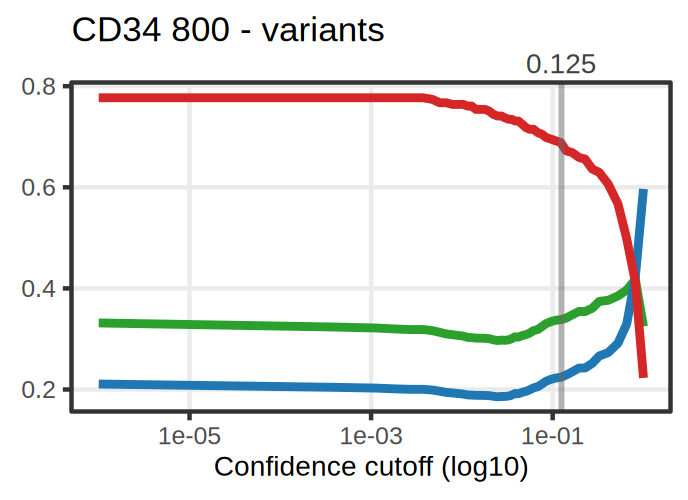

In [9]:
options(repr.plot.width = 2.75, repr.plot.height = 2, repr.plot.res = 250)
R.utils::sourceDirectory(glue('../../../tools/mitodrift/R'))

pr_df_var = compute_variant_pr_curve(phy_annot, mut_dat, j_thres = 0.5, min_vaf = 0.05, ncores = 8)
p = plot_prec_recall_vs_conf(pr_df_var, cutoff = p_conf, legend = F) + 
    ggtitle(glue('CD34 800 - variants'))

p

ggsave(glue('outputs/{sample}_variant_diag_curve.pdf'), p, width = 2.75, height = 2)

In [7]:
# write.tree(phy_prog_trim, '../../../../Lareau2020/phylosignal/invitro_800_prog_Day08_joint_phy_trim.newick')
# phy_prog_annot = phy_annot %>% keep_tip_safe(cells_prog)
# write.tree(phy_prog_annot, '../../../../Lareau2020/phylosignal/invitro_800_prog_Day08_joint_phy_nj.newick')

In [4]:
celltype_remap <- c(
	erythoid = "Erythroid",
	myeloid = "Myeloid",
	prog = "Progenitor",
	prog_ery = "Erythroid progenitor",
	prog_my = "Myeloid progenitor",
    mix = 'Mixed'
)

cell_annot = cell_annot %>% mutate(celltype_label = celltype_remap[celltype])

rename_group = c(
	ery1 = "Erythroid 1",
	ery2 = "Erythroid 2",
	ery3 = "Erythroid 3",
	ery4 = "Erythroid 4",
	ery5 = "Erythroid 5",
	ery6 = "Erythroid 6",
	mix = "Mixed",
	my1 = "Myeloid 1",
	my2 = "Myeloid 2",
	my3 = "Myeloid 3",
	my4 = "Myeloid 4",
	prog = "Progenitor",
	prog_ery = "Ery-Prog",
	prog_my = "Myelo-Prog"
)

cell_annot = cell_annot %>% mutate(group_label = rename_group[group])

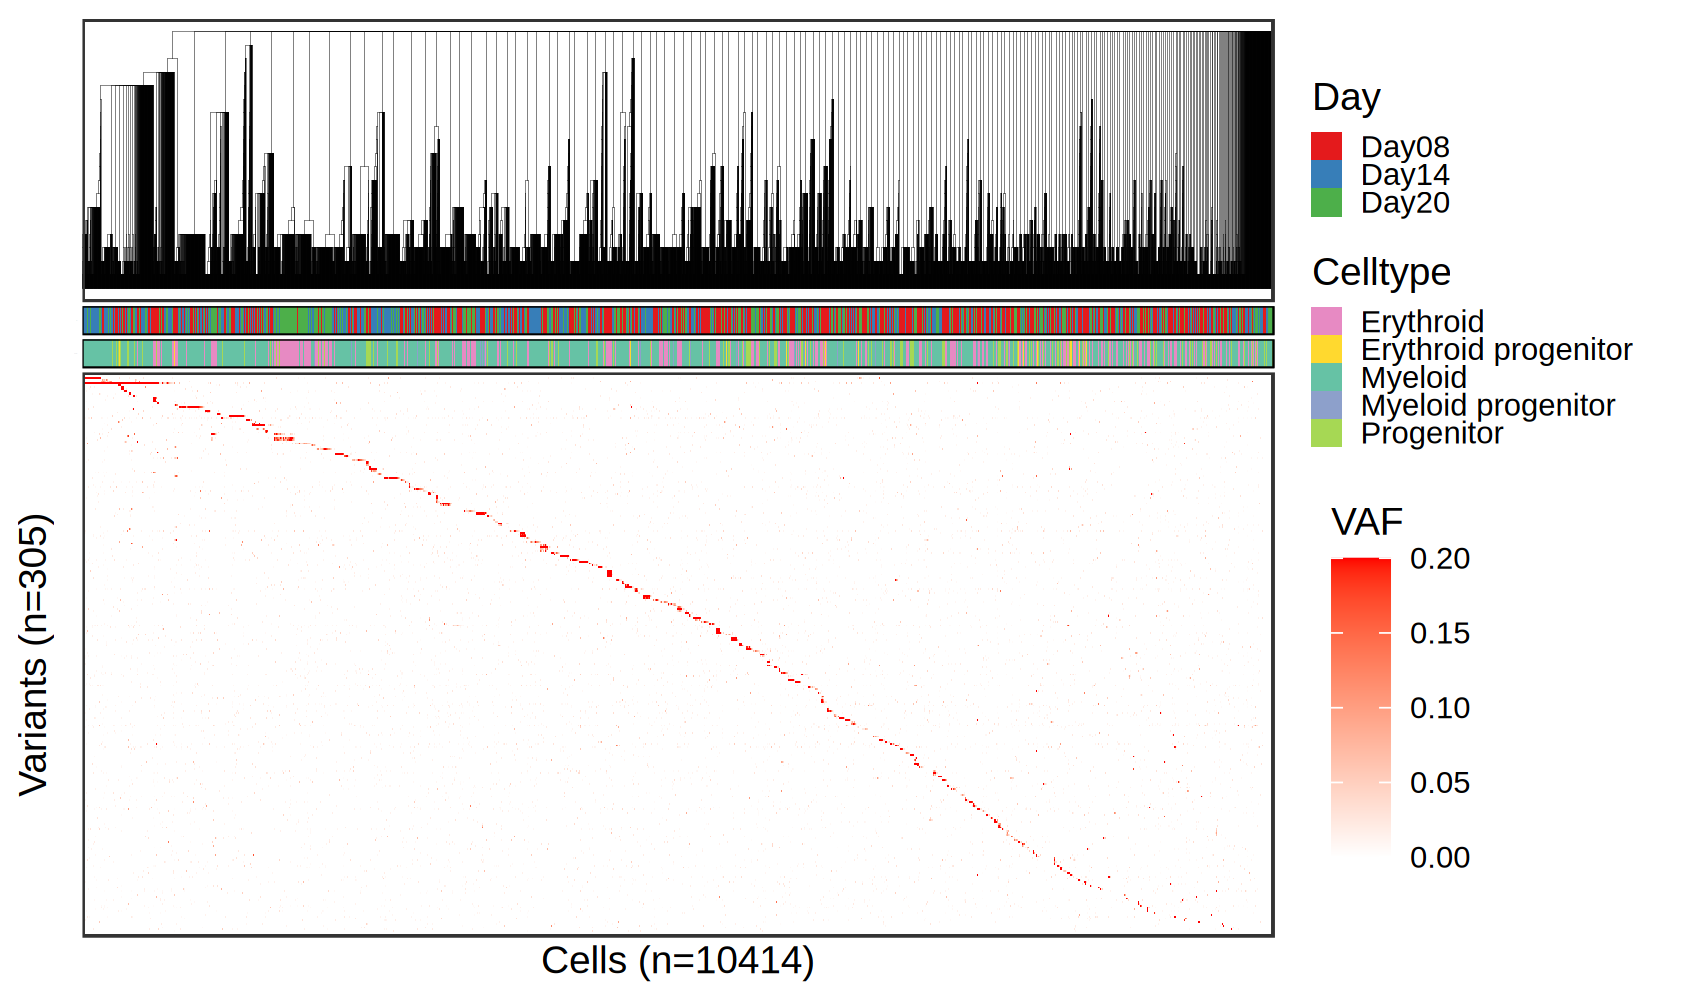

In [5]:
options(repr.plot.width = 6.75, repr.plot.height = 4, repr.plot.res = 250)
R.utils::sourceDirectory(glue('{home}/tools/mitodrift/R'))

pal_days = cell_annot$day %>% get_discrete_colors("Set1")
pal_ct = cell_annot$celltype_label %>% get_discrete_colors("Set2")

p = plot_phylo_heatmap2(
    phy_trim,
    mut_dat %>% group_by(variant) %>% filter(sum(a>0)>=15),
    node_conf = F,
    branch_length = F,
    branch_width = 0.05,
    het_max = 0.2,
    annot_legend = T,
    cell_annot = list(
        'Day' = cell_annot %>% mutate(annot = day),
        'Celltype' = cell_annot %>% mutate(annot = celltype_label)
    ),
    annot_pal = list(pal_days, pal_ct),
    annot_title_size = 0,
    show_variant_names = FALSE
) %>% suppressWarnings() %>%
suppressMessages()

p

ggsave('outputs/invitro_CD34_joint_tree.pdf', p, width = 6.75, height = 4)

# Lineage coupling

In [8]:
options(repr.plot.width = 3, repr.plot.height = 2, repr.plot.res = 200)

cluster_dict = cell_annot %>% {setNames(.$group_label, .$cell)}

res_path = run_path(phy_trim, cluster_dict[sample(names(cluster_dict))])

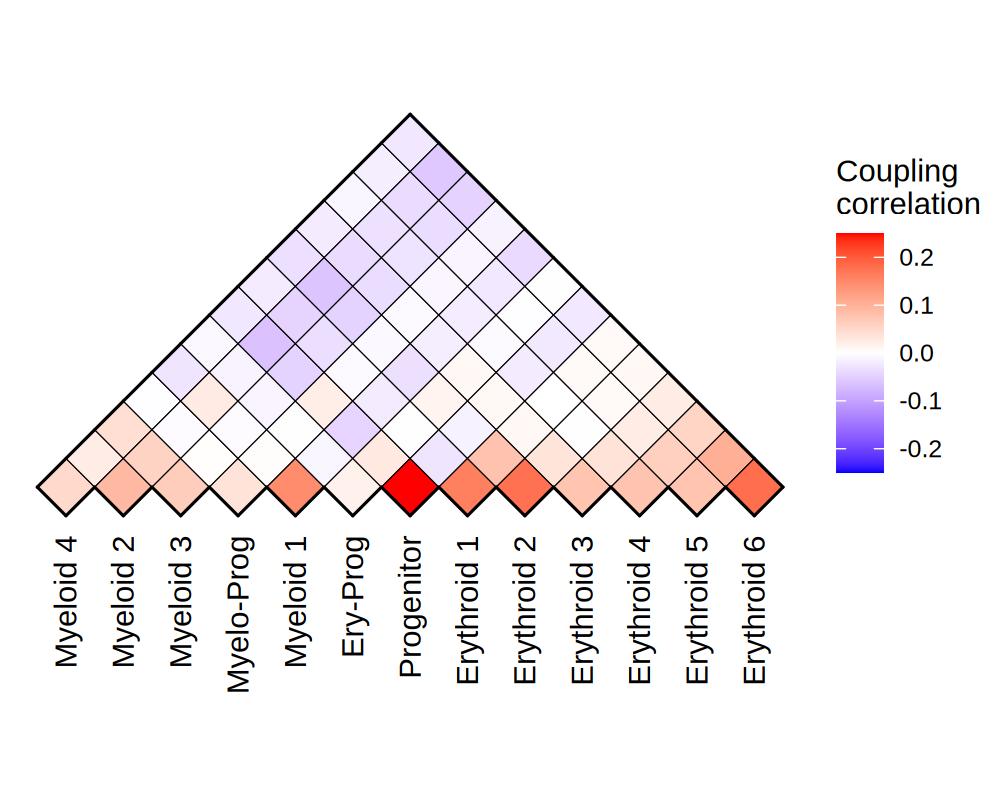

In [79]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)
R.utils::sourceDirectory(glue('{home}/mitodrift_analysis/R'))

p = plot_coupling_triangle(res_path, mark_signif = F, limits = c(-0.25, 0.25)) +
    theme(
        axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
        legend.position = "right"
    )

p

ggsave('outputs/invitro_CD34_coupling.pdf', p, width = 5, height = 4)

# Pseudotime heritability

In [5]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 200)
R.utils::sourceDirectory(glue('{home}/tools/mitodrift/R'))

pt_mat = cell_annot %>% 
    select(cell, My = my_pseudotime, Ery = ery_pseudotime) %>%
    tibble::column_to_rownames('cell') %>%
    t

In [6]:
phy_test = drop_singletons(phy_prog_trim)
score_dict = pt_mat['My',phy_test$tip.label]

# names(score_dict) = sample(names(score_dict))

phy_test = add_node_names(phy_test)
node_scores = compute_internal_node_scores(phy_test, score_dict, singletons = T, min_clade_size = 4)

score_dict = node_scores %>% {setNames(.$z_adj, .$label)}
score_dict_prop = propagate_scores_down_max(phy_test, score_dict, threshold = 0)
node_scores = node_scores %>% mutate(z_adj_prop = score_dict_prop[label])

Warning message in fortify(data, ...):
“Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• branch.length = branch.length
• hang = hang
• linewidth = branch_width
ℹ Did you misspell an argument name?”
Found more than one class "phylo" in cache; using the first, from namespace 'tidytree'

Also defined by ‘TreeTools’

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggtreeExtra package.
  Please report the issue at <https://github.com/YuLab-SMU/ggtreeExtra/issues>.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggtreeExtra package.
 

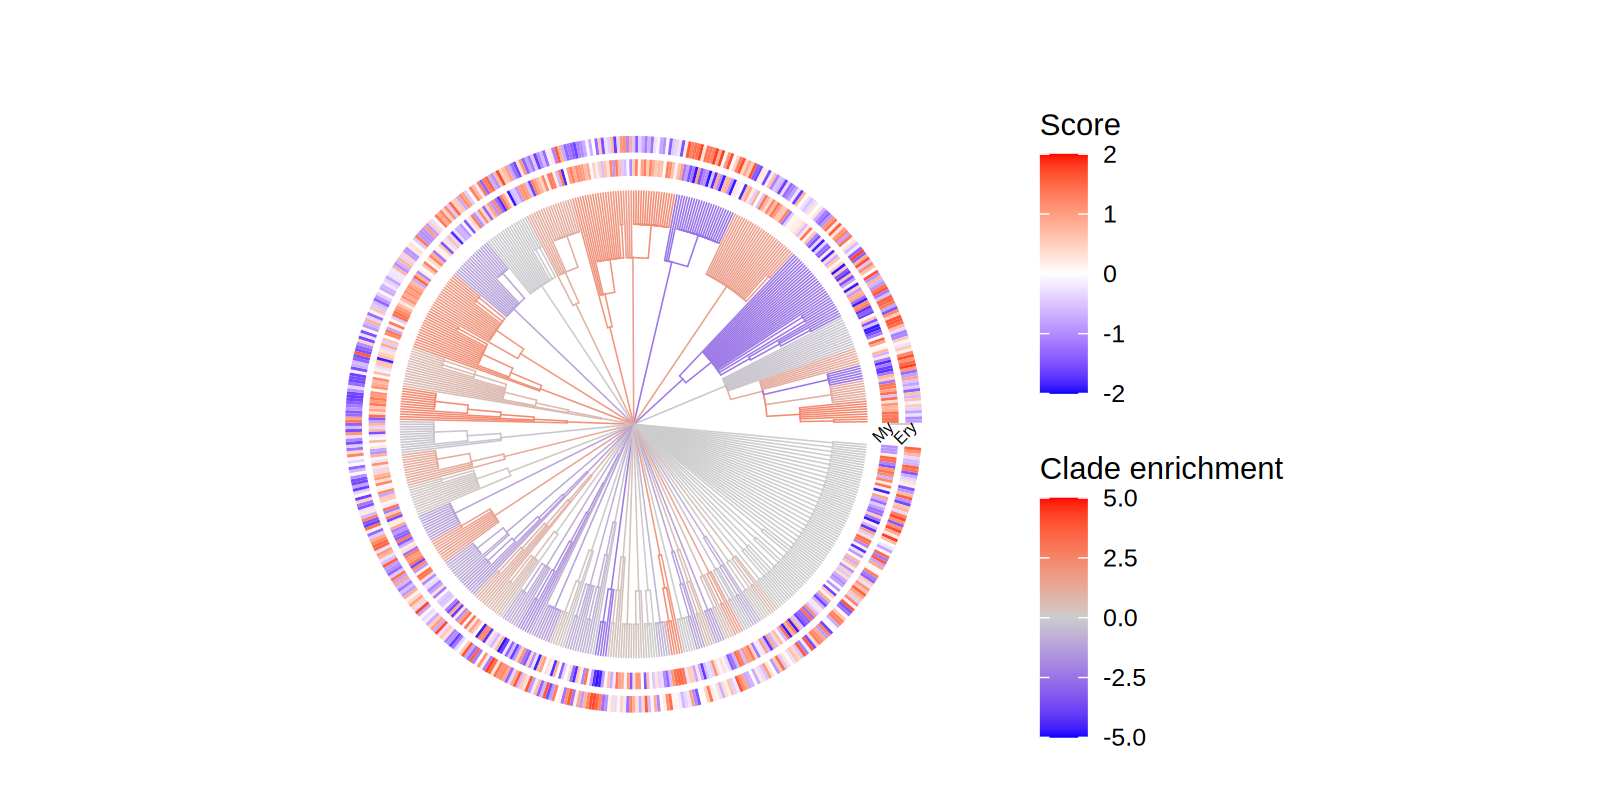

In [12]:
R.utils::sourceDirectory(glue('{home}/tools/mitodrift/R'))

p_tree = plot_phylo_circ(
    phy_test,
    branch_width = 0.2,
    pwidth_feature = 0.1,
    width = 0.5,
    rescale = T,
    annot_legend = T,
    feature_mat = pt_mat,
    open_angle = 5,
    feature_axis_angle = 45
)

p = p_tree %<+% node_scores +
	aes(color = z_adj_prop) +
	scale_color_gradient2(
        low = "blue", mid = 'gray80', high = "red",
        limits = c(-5,5), oob = scales::oob_squish, na.value = 'gray80',
        name = 'Clade enrichment'
    )

p

ggsave('outputs/invitro_CD34_prog_tree.pdf', p, width = 5, height = 4)

In [7]:
dat_signal = run_signal(pt_mat, phy_test, reps = 4999)

My

Ery



In [8]:
dat_signal

gene,cmean,pval,qval
<chr>,<dbl>,<dbl>,<dbl>
My,0.2150339,2e-04,2e-04
Ery,0.2258636,2e-04,2e-04


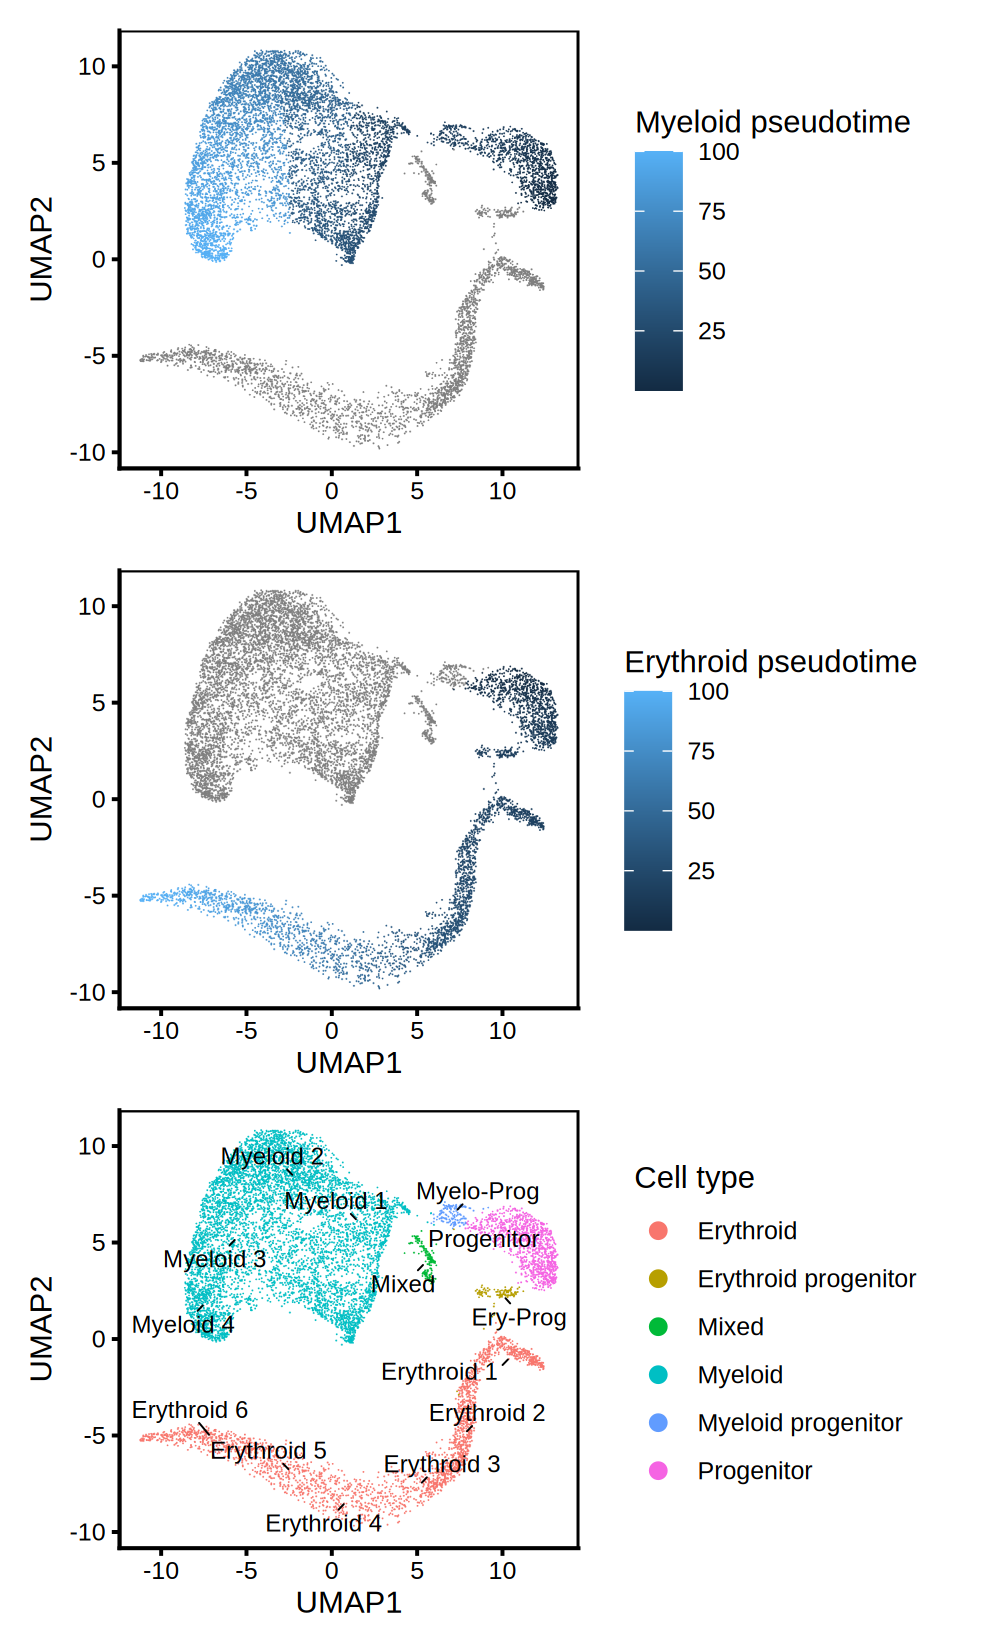

In [23]:
options(repr.plot.width = 5, repr.plot.height = 8.25, repr.plot.res = 200)

p1 = ggplot(
    	cell_annot,
    	aes(x = umap_x, y = umap_y, color = celltype_label)
    ) +
	theme_classic() +
	theme(panel.border = element_rect(size = 0.5, fill = NA)) +
	geom_point(size = 0.2, stroke = 0, show.legend = T) +
	guides(color = guide_legend(title = "Cell type", override.aes = list(size = 3))) +
	geom_text_repel(
		data = cell_annot %>%
			group_by(group_label) %>%
			summarise(
				umap_x = median(umap_x, na.rm = TRUE),
				umap_y = median(umap_y, na.rm = TRUE),
				.groups = "drop"
			),
		aes(x = umap_x, y = umap_y, label = group_label),
		inherit.aes = FALSE,
		size = 3,
		segment.size = 0.25,
		min.segment.length = 0,
		max.overlaps = Inf,
		box.padding = 0.3,
		point.padding = 0.2
	)

p2 = ggplot(
        cell_annot,
        aes(x = umap_x, y = umap_y, color = my_pseudotime)
    ) +
    theme_classic()+
    theme(panel.border = element_rect(size = 0.5)) +
    geom_point(size = 0.2, stroke = 0) +
    guides(color = guide_colorbar(title = 'Myeloid pseudotime'))

p3 = ggplot(
        cell_annot,
        aes(x = umap_x, y = umap_y, color = ery_pseudotime)
    ) +
    theme_classic() +
    theme(panel.border = element_rect(size = 0.5)) +
    geom_point(size = 0.2, stroke = 0) +
    guides(color = guide_colorbar(title = 'Erythroid pseudotime'))

p1 = p1 %>% ggrastr::rasterize(layers = 'Point', dpi = 300)
p2 = p2 %>% ggrastr::rasterize(layers = 'Point', dpi = 300)
p3 = p3 %>% ggrastr::rasterize(layers = 'Point', dpi = 300)

panel = (p2 / p3 / p1) & xlab('UMAP1') & ylab('UMAP2') &
    theme(legend.position = 'right', legend.title.position = 'top')

panel

ggsave('outputs/invitro_CD34_umap_overview.pdf', panel, width = 5, height = 8.75)

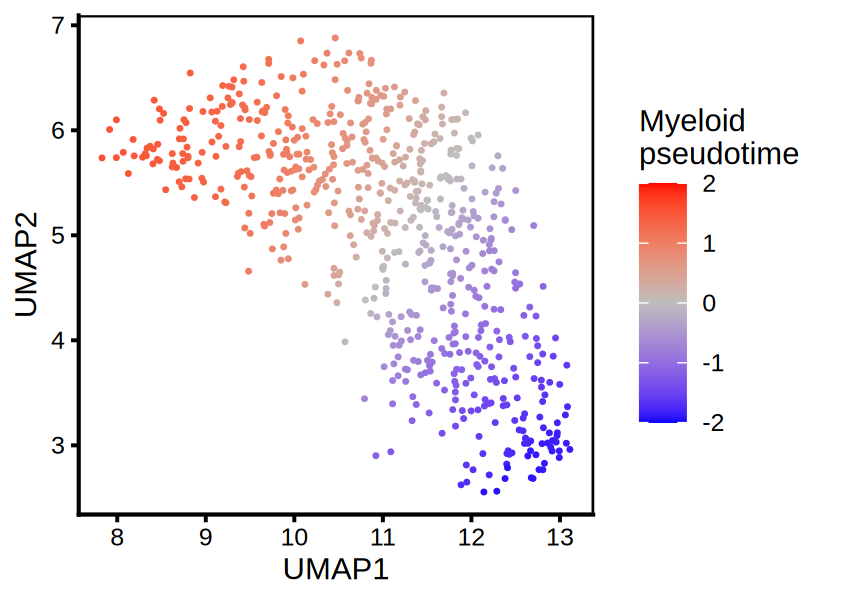

In [252]:
options(repr.plot.width = 4.25, repr.plot.height = 3, repr.plot.res = 200)

p = cell_annot %>% 
    filter(celltype %in% c('prog') & day %in% c('Day08')) %>%
    mutate(
        z_my_time = as.vector(scale(my_pseudotime))
    ) %>%
    ggplot(
        aes(x = umap_x, y = umap_y, color = z_my_time)
    ) +
    theme_classic() +
    theme(panel.border = element_rect(size = 0.5)) +
    geom_point(size = 1, stroke = 0) +
    guides(color = guide_colorbar(title = 'Myeloid\npseudotime')) +
    xlab('UMAP1') + 
    ylab('UMAP2') +
    scale_color_gradient2(
        low = 'blue', high = 'red', mid = 'gray', midpoint = 0,
        limits = c(-2,2), oob = scales::oob_squish, 
        na.value = 'transparent'
    )

p

ggsave('outputs/invitro_CD34_prog_pseudotime.pdf', p, width = 4, height = 3)

# Lineage bias

In [7]:
R.utils::sourceDirectory(glue('{home}/mitodrift_analysis/R'))

cells_subset = cell_annot %>% 
    filter(day %in% c('Day08') & celltype %in% c('prog', 'prog_my', 'prog_ery') | day %in% c('Day14', 'Day20') & celltype %in% c('myeloid', 'erythoid')) %>%
    pull(cell)

phy_test = phy_trim %>% keep_tip_safe(cells_subset)

lineage_dict = cell_annot %>% {setNames(.$celltype, .$cell)}

knn_stat = knn_category_counts(
    phy_test,
    lineage_dict, 
    k = 5,
    return_prop = T,
    include_self = F, 
    cat_exclude = c('prog', 'prog_my', 'prog_ery'),
    ncores = 3,
    seed = 0,
    ties = "random"
)

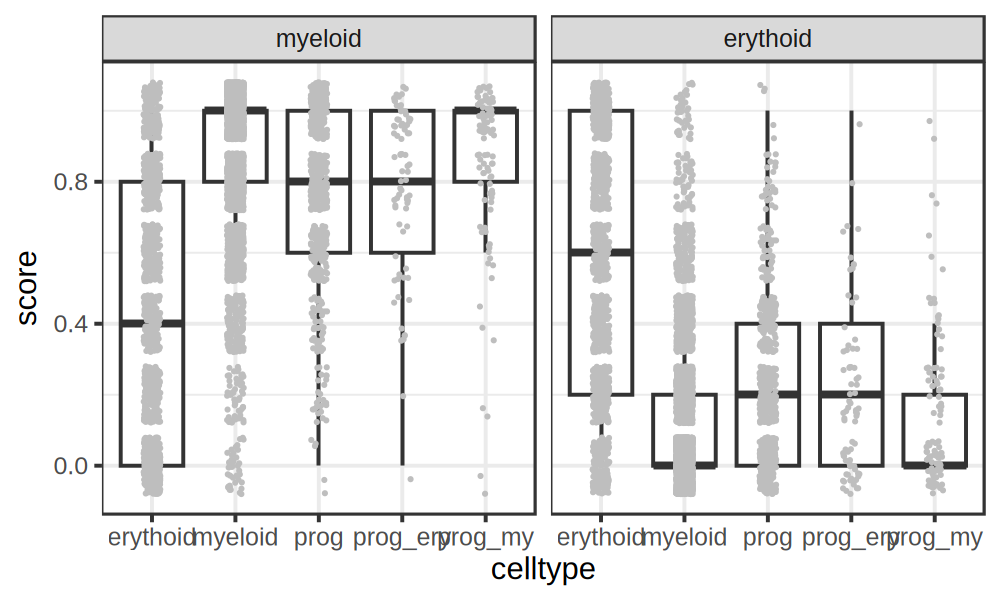

In [8]:
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 200)

knn_stat %>% tibble::rownames_to_column('cell') %>%
    left_join(cell_annot, by = join_by(cell)) %>%
    reshape2::melt(measure.vars = c('myeloid', 'erythoid'), value.name = 'score') %>%
    ggplot(
        aes(x = celltype, y = score)
    ) +
    theme_bw()+
    geom_boxplot(outlier.alpha = 0) +
    geom_jitter(width = 0.1, color = 'gray', size = 0.1) +
    facet_wrap(~variable)

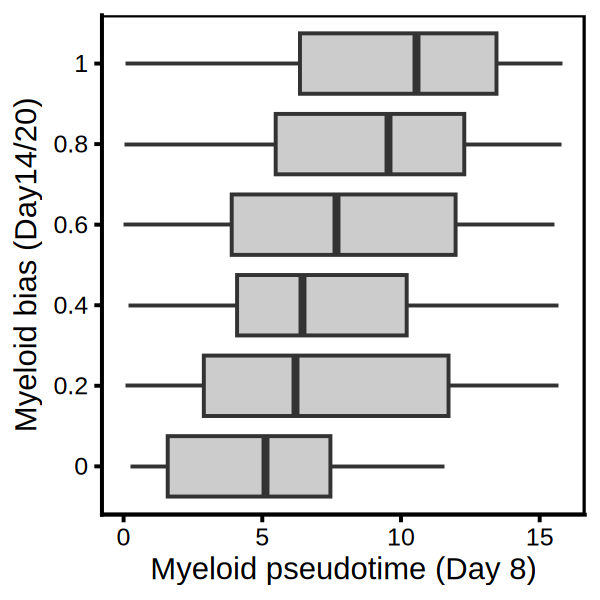

In [9]:
options(repr.plot.width = 3, repr.plot.height = 3, repr.plot.res = 200)

nbins = 20

D = knn_stat %>% 
    tibble::rownames_to_column('cell') %>%
    left_join(
        cell_annot, by = 'cell'
    ) %>%
    filter(celltype %in% c('prog') & day == 'Day08')

p = ggplot(D, aes(x = my_pseudotime, y = factor(myeloid))) +
	geom_boxplot(fill = 'gray80') +
    ylab('Myeloid bias (Day14/20)') +
    xlab('Myeloid pseudotime (Day 8)') +
    theme_classic() +
    theme(panel.border = element_rect(size = 0.5))

p

ggsave('outputs/invitro_CD34_bias_vs_pseudotime.pdf', p, width = 3, height = 3)

## TFs

In [10]:
tf_mat = fread('../../../Lareau2020/chromvar/CD34_800_Day08_chromvar_scores_original.csv') %>% tibble::column_to_rownames('V1')
cell_coverage = fread('../../../Lareau2020/cell_coverage.csv')

In [11]:
cells_prog = cell_annot %>% filter(celltype %in% c('prog')) %>% pull(cell)
cell_score_dict = knn_stat %>% filter(rownames(.) %in% cells_prog) %>% {setNames(.$myeloid, rownames(.))}

df_covar = cell_coverage %>% select(cell, depth, mtDNAcoverage) %>% tibble::column_to_rownames('cell')
test_dat = test_feature_regression_covar(tf_mat, cell_score_dict, df_covar, ncores = 1)

656 cells left after intersecting



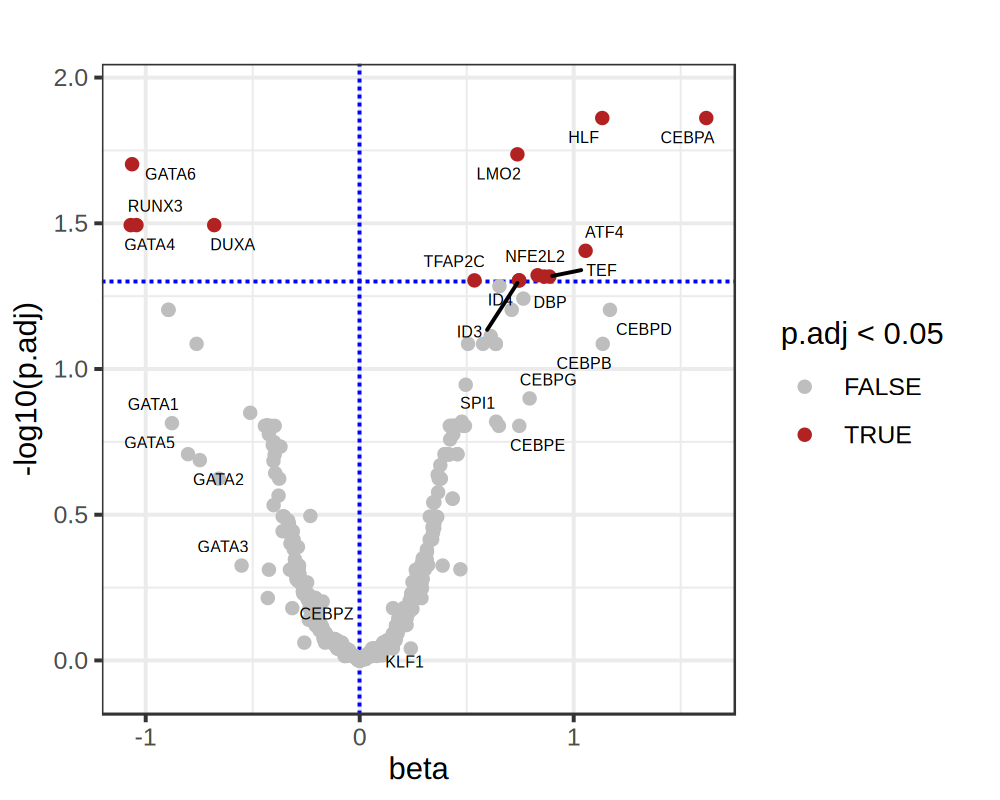

In [12]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

tfs_highlight = str_subset(test_dat$feature, 'GATA|SPI1|CEBP|KLF1$')

test_dat %>% plot_volcano(highlight = tfs_highlight)

Warning message:
“Removed 858 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message:
“Removed 858 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


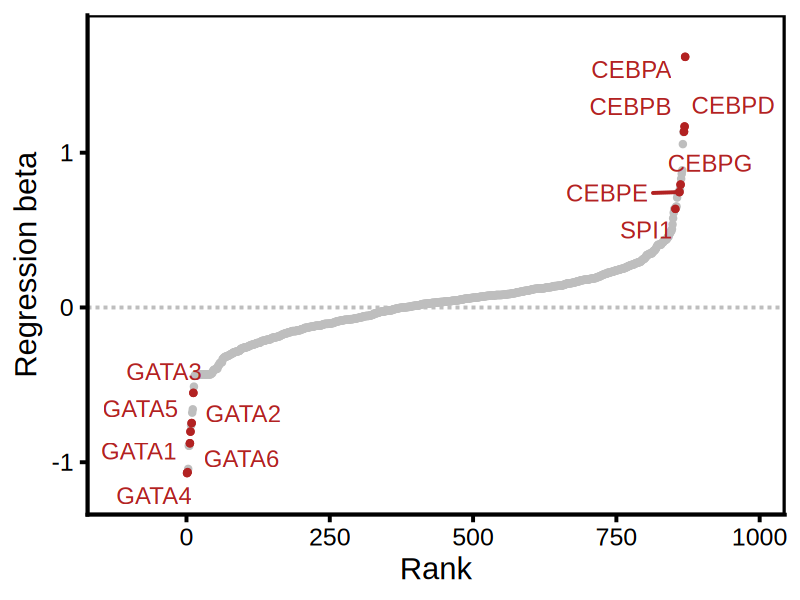

In [19]:
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 200)

tfs_highlight = c("CEBPA", "CEBPD", "CEBPB", "CEBPG", "CEBPE",
                  "SPI1", "GATA1", "GATA2", "GATA3", "GATA6", "GATA4", "GATA5")

D = test_dat %>% 
    mutate(
        s = ifelse(beta > 0, 1, -1),
        z_score = qnorm(p.value/2, lower.tail = FALSE) * s
    ) %>%
    mutate(rank = rank(beta, ties.method = 'random')) %>%
    mutate(label = ifelse(feature %in% tfs_highlight, feature, NA))

p = D %>% 
ggplot(
        aes(x = rank, y = beta, color = is.na(label))
    ) +
    geom_hline(yintercept = 0, color = 'gray', linetype = 'dashed') +
    geom_point(
        size = 0.5,
        show.legend = F
    ) +
    geom_point(
        data = D %>% filter(feature %in% tfs_highlight),
        size = 0.5,
        show.legend = F
    ) +
    theme_classic() +
    xlab('Rank') +
    ylab('Regression beta') +
    theme(panel.border = element_rect(size = 0.5)) +
    scale_x_continuous(expand = expansion(mult = 0.2)) +
    scale_y_continuous(expand = expansion(mult = 0.1)) +
    geom_text_repel(
        aes(label = label), max.overlaps = Inf,
        size = 3, show.legend = F
    ) +
    scale_color_manual(values = c('firebrick', 'gray'))

p

ggsave('outputs/invitro_CD34_tf_bias_rank.pdf', p, width = 4, height = 3)

# Heritability of TFs

In [39]:
test_res_all = bind_rows(
    fread(glue('../../../Lareau2020/phylosignal/invitro_800_prog_Day08_joint_trim_chromvar_cmeans.csv')) %>%
    mutate(method = 'MitoDrift'),
    fread(glue('../../../Lareau2020/phylosignal/invitro_800_prog_Day08_joint_nj_chromvar_cmeans.csv')) %>%
    mutate(method = 'NJ')
)

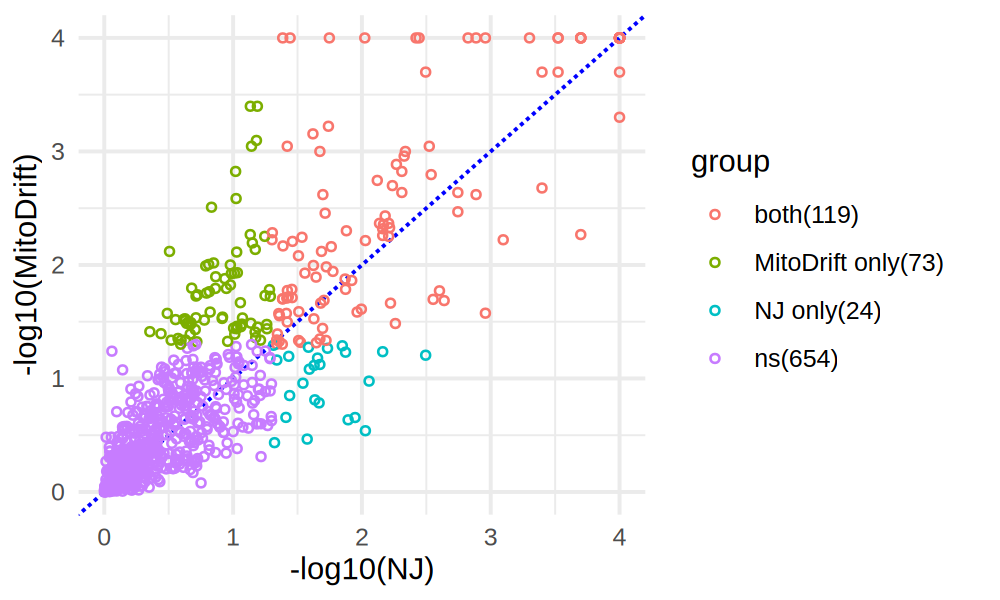

In [18]:
options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 200)

test_res_all %>%
reshape2::dcast(gene ~ method, value.var = 'pval') %>%
mutate(
    group = case_when(
        NJ < 0.05 & MitoDrift < 0.05 ~ 'both',
        NJ > 0.05 & MitoDrift < 0.05 ~ 'MitoDrift only',
        NJ < 0.05 & MitoDrift > 0.05 ~ 'NJ only',
        T ~ 'ns'
    )
) %>%
group_by(group) %>%
mutate(n = n()) %>%
ungroup() %>%
mutate(group = paste0(group, '(', n, ')')) %>%
ggplot(
    aes(x = -log10(NJ), y = -log10(MitoDrift), color = group)
) +
theme_minimal() +
geom_abline(color = 'blue', linetype = 'dashed') + 
geom_point(size = 1, pch = 21)

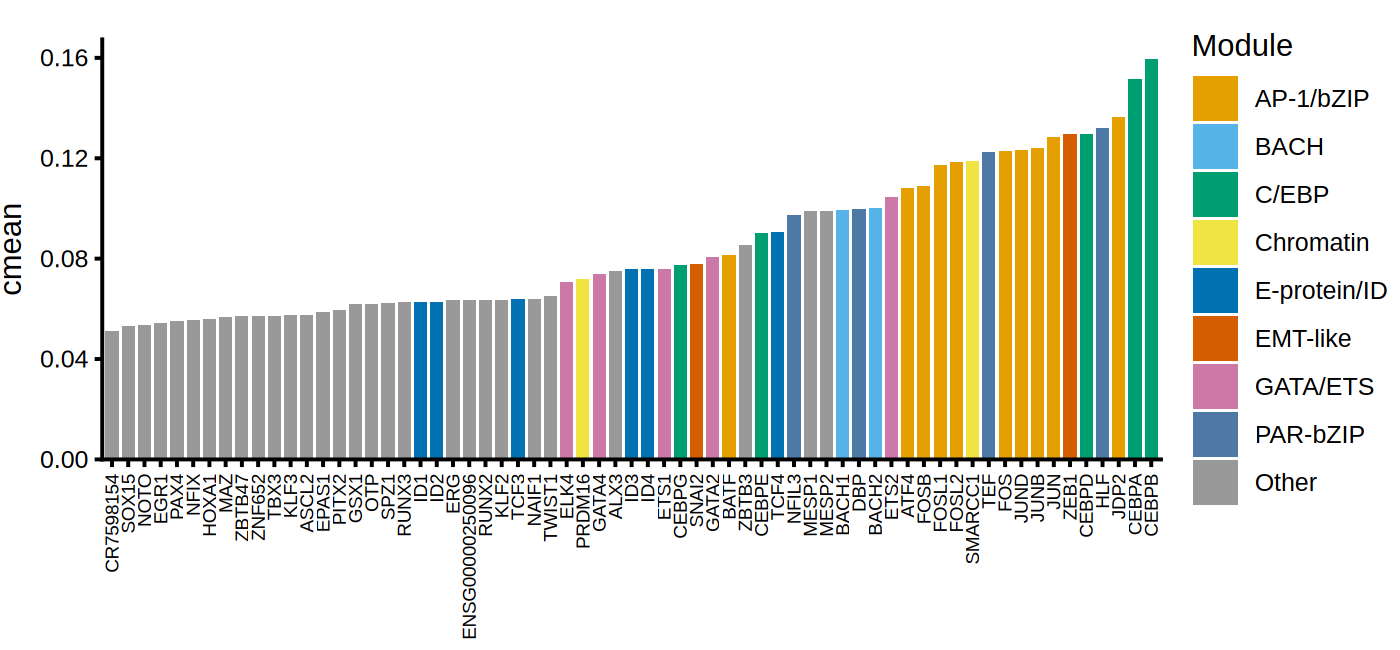

In [74]:
options(repr.plot.width = 7, repr.plot.height = 3.25, repr.plot.res = 200)

# ---- module assignment ----
dat = test_res_all %>%
	filter(method == "MitoDrift") %>%
	filter(qval < 0.05) %>%
	mutate(
		module = case_when(
			str_detect(gene, "^CEBP") ~ "C/EBP",
			gene %in% c("JUN","JUNB","JUND","FOS","FOSB","FOSL1","FOSL2","BATF","ATF3","ATF4","JDP2") ~ "AP-1/bZIP",
			gene %in% c("HLF","DBP","TEF","NFIL3") ~ "PAR-bZIP",
			str_detect(gene, "^GATA") | gene %in% c("ETS1","ETS2","ELK4") ~ "GATA/ETS",
			gene %in% c("TCF3","TCF4","TCF12","E2A","HEB") ~ "E-protein/ID",
			gene %in% c("ID1","ID2","ID3","ID4") ~ "E-protein/ID",
			gene %in% c("BACH1","BACH2") ~ "BACH",
			gene %in% c("SMARCC1","PRDM16") ~ "Chromatin",
			gene %in% c("ZEB1","ZEB2","SNAI1","SNAI2") ~ "EMT-like",
			TRUE ~ "Other"
		)
	) %>%
	arrange(desc(cmean)) %>%
	mutate(
		rank = dplyr::row_number(),
		neglogq = -log10(pmax(qval, .Machine$double.eps))
	)

# Make "Other" last in legend (and generally)
mods = unique(dat$module)
mods_no_other = sort(setdiff(mods, "Other"))
mod_levels = c(mods_no_other, "Other")

dat$module = factor(dat$module, levels = mod_levels)

# Palette
base = c(
	"#E69F00","#56B4E9","#009E73","#F0E442","#0072B2",
	"#D55E00","#CC79A7","#4E79A7","#59A14F",
	"#B07AA1","#F28E2B"
)

pal = setNames(rep(base, length.out = length(mod_levels)), mod_levels)

# force Other to gray (and keep it last)
if ("Other" %in% names(pal)) pal["Other"] = "#999999"

p = ggplot(dat, aes(x = reorder(gene, cmean), y = cmean, fill = module)) +
	geom_col(width = 0.75) +
	scale_fill_manual(values = pal, drop = FALSE) +
	labs(x = NULL, y = "cmean", fill = "Module") +
	theme_classic(base_size = 11) +
	scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
	theme(axis.text.x = element_text(size = 6.5, angle = 90, hjust = 1, vjust = 0.5)) +
    theme(margins = margin(t = 5, unit = 'mm'))

p

ggsave('outputs/invitro_CD34_heritable_tfs.pdf', p, width = 7, height = 3.25)